# Notebook 1 — Imputation Strategies

**Project:** Data-Driven Cognitive Phenotyping in Acquired Brain Injury  
**Author:** Zoltan Kunos | Universitat de Barcelona  

Implements 8 imputation methods on the 17,423 x 16 eligible-variable matrix:
1. Mean Imputation
2. K-Nearest Neighbours (KNN)
3. MICE (Multiple Imputation by Chained Equations)
4. MissForest
5. Predictive Mean Matching (PMM)
6. Expectation-Maximisation (EM)
7. SoftImpute
8. NMF (Non-Negative Matrix Factorisation)

Integrates Afkanpour et al. (2024) taxonomy.

In [1]:
# === Configuration ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import NMF
from scipy.spatial.distance import cdist

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

DATA_DIR = '../data'
IMPUTED_DIR = '../data/imputed_csv'
RESULTS_DIR = '../results'
FIGURES_DIR = '../report template/Figures'
os.makedirs(IMPUTED_DIR, exist_ok=True)

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Load EDA outputs
with open(os.path.join(RESULTS_DIR, 'eda_output.pkl'), 'rb') as f:
    eda = pickle.load(f)

ELIGIBLE_VARS = eda['ELIGIBLE_VARS']
DOMAINS = eda['DOMAINS']
df_eligible = eda['df_eligible']

# Extract the eligible variable matrix
X = df_eligible[ELIGIBLE_VARS].copy()
print(f'Imputation matrix shape: {X.shape}')
print(f'Overall missing rate: {X.isnull().mean().mean()*100:.1f}%')

Imputation matrix shape: (22075, 15)
Overall missing rate: 29.6%


## Afkanpour et al. (2024) Taxonomy

Classification of the 8 imputation methods according to the systematic review by Afkanpour et al. (2024), *BMC Medical Research Methodology*, 24(1), 188.

| Method | Afkanpour Category | Prevalence | Notes |
|--------|-------------------|------------|-------|
| Mean | Conventional Statistical (41%) | Baseline | Simple, biased variance |
| KNN | Machine Learning (24%) | Common | Distance-weighted |
| MICE | Conventional Statistical (41%) | Gold standard (41% of studies) | Chained equations |
| MissForest | Machine Learning (24%) | Competitive | Non-parametric, RF-based |
| PMM | Conventional Statistical (41%) | Common in MI | Preserves distribution |
| EM | Conventional Statistical (41%) | Classical | Assumes multivariate normality |
| SoftImpute | Matrix Completion (11%) | Emerging | Nuclear norm regularisation |
| NMF | Hybrid (24%) | Emerging | Non-negative decomposition |

**Key findings from Afkanpour et al. (2024):**
- MICE was the most commonly used gold standard (41% of reviewed studies)
- No single imputation method is universally superior
- MissForest is competitive for mixed-type data
- Method selection should be data-driven

In [3]:
# Create imputation flags matrix (1 = was missing, 0 = was observed)
imputation_flags = X.isnull().astype(int)
imputation_flags.to_csv(os.path.join(IMPUTED_DIR, 'Imputation_Flags.csv'))
print(f'Imputation flags saved. Total missing values: {imputation_flags.sum().sum():,}')

# Storage for all imputed datasets
imputed_datasets = {}

Imputation flags saved. Total missing values: 97,965


## Method 1: Mean Imputation

In [4]:
print('=== Method 1: Mean Imputation ===')
imputer_mean = SimpleImputer(strategy='mean')
X_mean = pd.DataFrame(imputer_mean.fit_transform(X), columns=ELIGIBLE_VARS, index=X.index)

imputed_datasets['Mean'] = X_mean
X_mean.to_csv(os.path.join(IMPUTED_DIR, 'Imputed_Mean.csv'))
print(f'Shape: {X_mean.shape}, Missing remaining: {X_mean.isnull().sum().sum()}')
print('Saved: Imputed_Mean.csv')

=== Method 1: Mean Imputation ===
Shape: (22075, 15), Missing remaining: 0
Saved: Imputed_Mean.csv


## Method 2: K-Nearest Neighbours (KNN)

In [5]:
print('=== Method 2: KNN Imputation ===')
imputer_knn = KNNImputer(n_neighbors=5, weights='distance')
X_knn = pd.DataFrame(imputer_knn.fit_transform(X), columns=ELIGIBLE_VARS, index=X.index)

imputed_datasets['KNN'] = X_knn
X_knn.to_csv(os.path.join(IMPUTED_DIR, 'Imputed_KNN.csv'))
print(f'Shape: {X_knn.shape}, Missing remaining: {X_knn.isnull().sum().sum()}')
print('Saved: Imputed_KNN.csv')

=== Method 2: KNN Imputation ===


Shape: (22075, 15), Missing remaining: 0
Saved: Imputed_KNN.csv


## Method 3: MICE (Multiple Imputation by Chained Equations)

In [6]:
print('=== Method 3: MICE Imputation ===')
# Generate m=5 imputed datasets and pool (Rubin\'s rules)
m = 5
mice_imputations = []

for i in range(m):
    imputer_mice = IterativeImputer(
        estimator=BayesianRidge(),
        max_iter=10,
        sample_posterior=True,
        random_state=RANDOM_STATE + i
    )
    X_mice_i = pd.DataFrame(
        imputer_mice.fit_transform(X), columns=ELIGIBLE_VARS, index=X.index
    )
    mice_imputations.append(X_mice_i)
    print(f'  MICE iteration {i+1}/{m} complete')

# Pool using Rubin's combining rules (average point estimates)
X_mice = pd.concat(mice_imputations).groupby(level=0).mean()

imputed_datasets['MICE'] = X_mice
X_mice.to_csv(os.path.join(IMPUTED_DIR, 'Imputed_MICE.csv'))
print(f'Shape: {X_mice.shape}, Missing remaining: {X_mice.isnull().sum().sum()}')
print('Saved: Imputed_MICE.csv')

=== Method 3: MICE Imputation ===


  MICE iteration 1/5 complete


  MICE iteration 2/5 complete


  MICE iteration 3/5 complete


  MICE iteration 4/5 complete


  MICE iteration 5/5 complete
Shape: (22075, 15), Missing remaining: 0
Saved: Imputed_MICE.csv


## Method 4: MissForest

In [7]:
print('=== Method 4: MissForest Imputation ===')
imputer_mf = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
    max_iter=10,
    random_state=RANDOM_STATE
)
X_mf = pd.DataFrame(imputer_mf.fit_transform(X), columns=ELIGIBLE_VARS, index=X.index)

imputed_datasets['MissForest'] = X_mf
X_mf.to_csv(os.path.join(IMPUTED_DIR, 'Imputed_MissForest.csv'))
print(f'Shape: {X_mf.shape}, Missing remaining: {X_mf.isnull().sum().sum()}')
print('Saved: Imputed_MissForest.csv')

=== Method 4: MissForest Imputation ===


Shape: (22075, 15), Missing remaining: 0
Saved: Imputed_MissForest.csv


## Method 5: Predictive Mean Matching (PMM)

In [8]:
print('=== Method 5: PMM Imputation ===')

def pmm_impute(data, n_donors=5, max_iter=10, random_state=42):
    """Custom Predictive Mean Matching implementation."""
    rng = np.random.RandomState(random_state)
    X_imp = data.copy().values.astype(float)
    col_names = data.columns.tolist()
    n, p = X_imp.shape
    
    # Initial fill with column means for regression
    col_means = np.nanmean(X_imp, axis=0)
    for j in range(p):
        mask = np.isnan(X_imp[:, j])
        X_imp[mask, j] = col_means[j]
    
    missing_mask = data.isnull().values
    
    for iteration in range(max_iter):
        for j in range(p):
            if not missing_mask[:, j].any():
                continue
            
            obs_idx = ~missing_mask[:, j]
            mis_idx = missing_mask[:, j]
            
            # Predictors: all other columns
            pred_cols = [k for k in range(p) if k != j]
            X_pred = X_imp[:, pred_cols]
            
            # Fit linear regression on observed
            reg = LinearRegression()
            reg.fit(X_pred[obs_idx], X_imp[obs_idx, j])
            
            # Predict for observed and missing
            y_hat_obs = reg.predict(X_pred[obs_idx])
            y_hat_mis = reg.predict(X_pred[mis_idx])
            
            # Match each missing to closest observed predictions
            observed_values = data.values[obs_idx, j]
            for i, y_m in enumerate(y_hat_mis):
                distances = np.abs(y_hat_obs - y_m)
                donor_indices = np.argsort(distances)[:n_donors]
                donor = rng.choice(donor_indices)
                X_imp[np.where(mis_idx)[0][i], j] = observed_values[donor]
    
    return pd.DataFrame(X_imp, columns=col_names, index=data.index)

X_pmm = pmm_impute(X, n_donors=5, max_iter=10, random_state=RANDOM_STATE)

imputed_datasets['PMM'] = X_pmm
X_pmm.to_csv(os.path.join(IMPUTED_DIR, 'Imputed_PMM.csv'))
print(f'Shape: {X_pmm.shape}, Missing remaining: {X_pmm.isnull().sum().sum()}')
print('Saved: Imputed_PMM.csv')

=== Method 5: PMM Imputation ===


Shape: (22075, 15), Missing remaining: 0
Saved: Imputed_PMM.csv


## Method 6: Expectation-Maximisation (EM)

In [9]:
print('=== Method 6: EM Imputation ===')

def em_impute(data, max_iter=100, tol=1e-6, random_state=42):
    """EM algorithm for missing data assuming multivariate normality.
    Reference: Dempster, Laird & Rubin (1977)."""
    rng = np.random.RandomState(random_state)
    X_imp = data.copy().values.astype(float)
    n, p = X_imp.shape
    missing_mask = np.isnan(X_imp)
    
    # Initialise with column means
    col_means = np.nanmean(X_imp, axis=0)
    for j in range(p):
        X_imp[missing_mask[:, j], j] = col_means[j]
    
    for iteration in range(max_iter):
        X_old = X_imp.copy()
        
        # M-step: estimate parameters
        mu = np.mean(X_imp, axis=0)
        Sigma = np.cov(X_imp, rowvar=False)
        
        # Regularise covariance to prevent singularity
        Sigma += np.eye(p) * 1e-6
        
        # E-step: impute missing values
        for i in range(n):
            mis_j = np.where(missing_mask[i])[0]
            obs_j = np.where(~missing_mask[i])[0]
            
            if len(mis_j) == 0 or len(obs_j) == 0:
                continue
            
            # Conditional expectation
            Sigma_mo = Sigma[np.ix_(mis_j, obs_j)]
            Sigma_oo = Sigma[np.ix_(obs_j, obs_j)]
            Sigma_oo_inv = np.linalg.solve(Sigma_oo, np.eye(len(obs_j)))
            
            X_imp[i, mis_j] = mu[mis_j] + Sigma_mo @ Sigma_oo_inv @ (X_imp[i, obs_j] - mu[obs_j])
        
        # Check convergence
        change = np.mean((X_imp - X_old) ** 2)
        if change < tol:
            print(f'  EM converged at iteration {iteration + 1} (change={change:.2e})')
            break
    else:
        print(f'  EM reached max iterations ({max_iter}), change={change:.2e}')
    
    return pd.DataFrame(X_imp, columns=data.columns, index=data.index)

X_em = em_impute(X, max_iter=100, tol=1e-6, random_state=RANDOM_STATE)

imputed_datasets['EM'] = X_em
X_em.to_csv(os.path.join(IMPUTED_DIR, 'Imputed_EM.csv'))
print(f'Shape: {X_em.shape}, Missing remaining: {X_em.isnull().sum().sum()}')
print('Saved: Imputed_EM.csv')

=== Method 6: EM Imputation ===


  EM converged at iteration 80 (change=9.37e-07)
Shape: (22075, 15), Missing remaining: 0
Saved: Imputed_EM.csv


## Method 7: SoftImpute

In [10]:
print('=== Method 7: SoftImpute ===')

def soft_impute(data, rank=8, max_iter=100, tol=1e-5, random_state=42):
    """Iterative soft-thresholded SVD for matrix completion.
    Reference: Mazumder, Hastie & Tibshirani (2010)."""
    X_imp = data.copy().values.astype(float)
    n, p = X_imp.shape
    missing_mask = np.isnan(X_imp)
    
    # Initialise missing with column means
    col_means = np.nanmean(X_imp, axis=0)
    for j in range(p):
        X_imp[missing_mask[:, j], j] = col_means[j]
    
    for iteration in range(max_iter):
        X_old = X_imp.copy()
        
        # SVD
        U, s, Vt = np.linalg.svd(X_imp, full_matrices=False)
        
        # Soft-threshold: keep top `rank` singular values
        s_trunc = np.zeros_like(s)
        s_trunc[:rank] = s[:rank]
        
        # Reconstruct
        X_reconstructed = U @ np.diag(s_trunc) @ Vt
        
        # Update only missing entries
        X_imp[missing_mask] = X_reconstructed[missing_mask]
        
        # Check convergence
        change = np.mean((X_imp[missing_mask] - X_old[missing_mask]) ** 2)
        if change < tol:
            print(f'  SoftImpute converged at iteration {iteration + 1} (change={change:.2e})')
            break
    else:
        print(f'  SoftImpute reached max iterations ({max_iter}), change={change:.2e}')
    
    return pd.DataFrame(X_imp, columns=data.columns, index=data.index)

X_soft = soft_impute(X, rank=8, max_iter=100, tol=1e-5, random_state=RANDOM_STATE)

imputed_datasets['SoftImpute'] = X_soft
X_soft.to_csv(os.path.join(IMPUTED_DIR, 'Imputed_SoftImpute.csv'))
print(f'Shape: {X_soft.shape}, Missing remaining: {X_soft.isnull().sum().sum()}')
print('Saved: Imputed_SoftImpute.csv')

=== Method 7: SoftImpute ===


  SoftImpute reached max iterations (100), change=2.53e-04
Shape: (22075, 15), Missing remaining: 0
Saved: Imputed_SoftImpute.csv


## Method 8: Non-Negative Matrix Factorisation (NMF)

In [11]:
print('=== Method 8: NMF Imputation ===')

def nmf_impute(data, n_components=8, max_iter=200, tol=1e-5, random_state=42):
    """NMF-based imputation. Requires non-negative input."""
    X_imp = data.copy().values.astype(float)
    n, p = X_imp.shape
    missing_mask = np.isnan(X_imp)
    
    # Clip to non-negative (NMF requirement)
    X_clipped = np.nanmax(np.stack([X_imp, np.zeros_like(X_imp)]), axis=0)
    
    # Initialise missing with column means (also clipped)
    col_means = np.nanmean(X_clipped, axis=0)
    col_means = np.maximum(col_means, 1e-6)  # Ensure positive
    for j in range(p):
        X_clipped[missing_mask[:, j], j] = col_means[j]
    
    # Ensure all values are positive
    X_clipped = np.maximum(X_clipped, 1e-6)
    
    for iteration in range(max_iter):
        X_old = X_clipped.copy()
        
        # Fit NMF
        model = NMF(n_components=n_components, init='nndsvda', max_iter=200,
                     random_state=random_state, tol=1e-4)
        W = model.fit_transform(X_clipped)
        H = model.components_
        
        # Reconstruct and update missing
        X_reconstructed = W @ H
        X_clipped[missing_mask] = X_reconstructed[missing_mask]
        X_clipped = np.maximum(X_clipped, 1e-6)
        
        # Check convergence
        change = np.mean((X_clipped[missing_mask] - X_old[missing_mask]) ** 2)
        if change < tol:
            print(f'  NMF converged at iteration {iteration + 1} (change={change:.2e})')
            break
    else:
        print(f'  NMF reached max iterations ({max_iter}), change={change:.2e}')
    
    # Replace back into original scale (only missing values are from NMF)
    X_result = data.copy().values.astype(float)
    X_result[missing_mask] = X_clipped[missing_mask]
    
    return pd.DataFrame(X_result, columns=data.columns, index=data.index)

X_nmf = nmf_impute(X, n_components=8, max_iter=200, tol=1e-5, random_state=RANDOM_STATE)

imputed_datasets['NMF'] = X_nmf
X_nmf.to_csv(os.path.join(IMPUTED_DIR, 'Imputed_NMF.csv'))
print(f'Shape: {X_nmf.shape}, Missing remaining: {X_nmf.isnull().sum().sum()}')
print('Saved: Imputed_NMF.csv')

=== Method 8: NMF Imputation ===


  NMF reached max iterations (200), change=6.97e-03
Shape: (22075, 15), Missing remaining: 0
Saved: Imputed_NMF.csv


## Imputation Comparison

In [12]:
# Summary statistics across all methods
summary_rows = []
for method, X_imp in imputed_datasets.items():
    summary_rows.append({
        'Method': method,
        'Missing Remaining': X_imp.isnull().sum().sum(),
        'Mean (all vars)': X_imp.mean().mean(),
        'Std (all vars)': X_imp.std().mean(),
        'Min': X_imp.min().min(),
        'Max': X_imp.max().max()
    })

summary_df = pd.DataFrame(summary_rows)
print('=== Imputation Summary ===')
print(summary_df.to_string(index=False))

=== Imputation Summary ===
    Method  Missing Remaining  Mean (all vars)  Std (all vars)        Min   Max
      Mean                  0        20.088081        6.886488   0.000000 999.0
       KNN                  0        20.389218        8.336408   0.000000 999.0
      MICE                  0        20.775293        8.374558 -54.786989 999.0
MissForest                  0        21.610278       10.843710   0.000000 999.0
       PMM                  0        20.730807        9.860420   0.000000 999.0
        EM                  0        20.878413        8.554922 -55.037261 999.0
SoftImpute                  0        20.096812        7.185108 -52.915131 999.0
       NMF                  0        17.730974        8.194744   0.000000 999.0


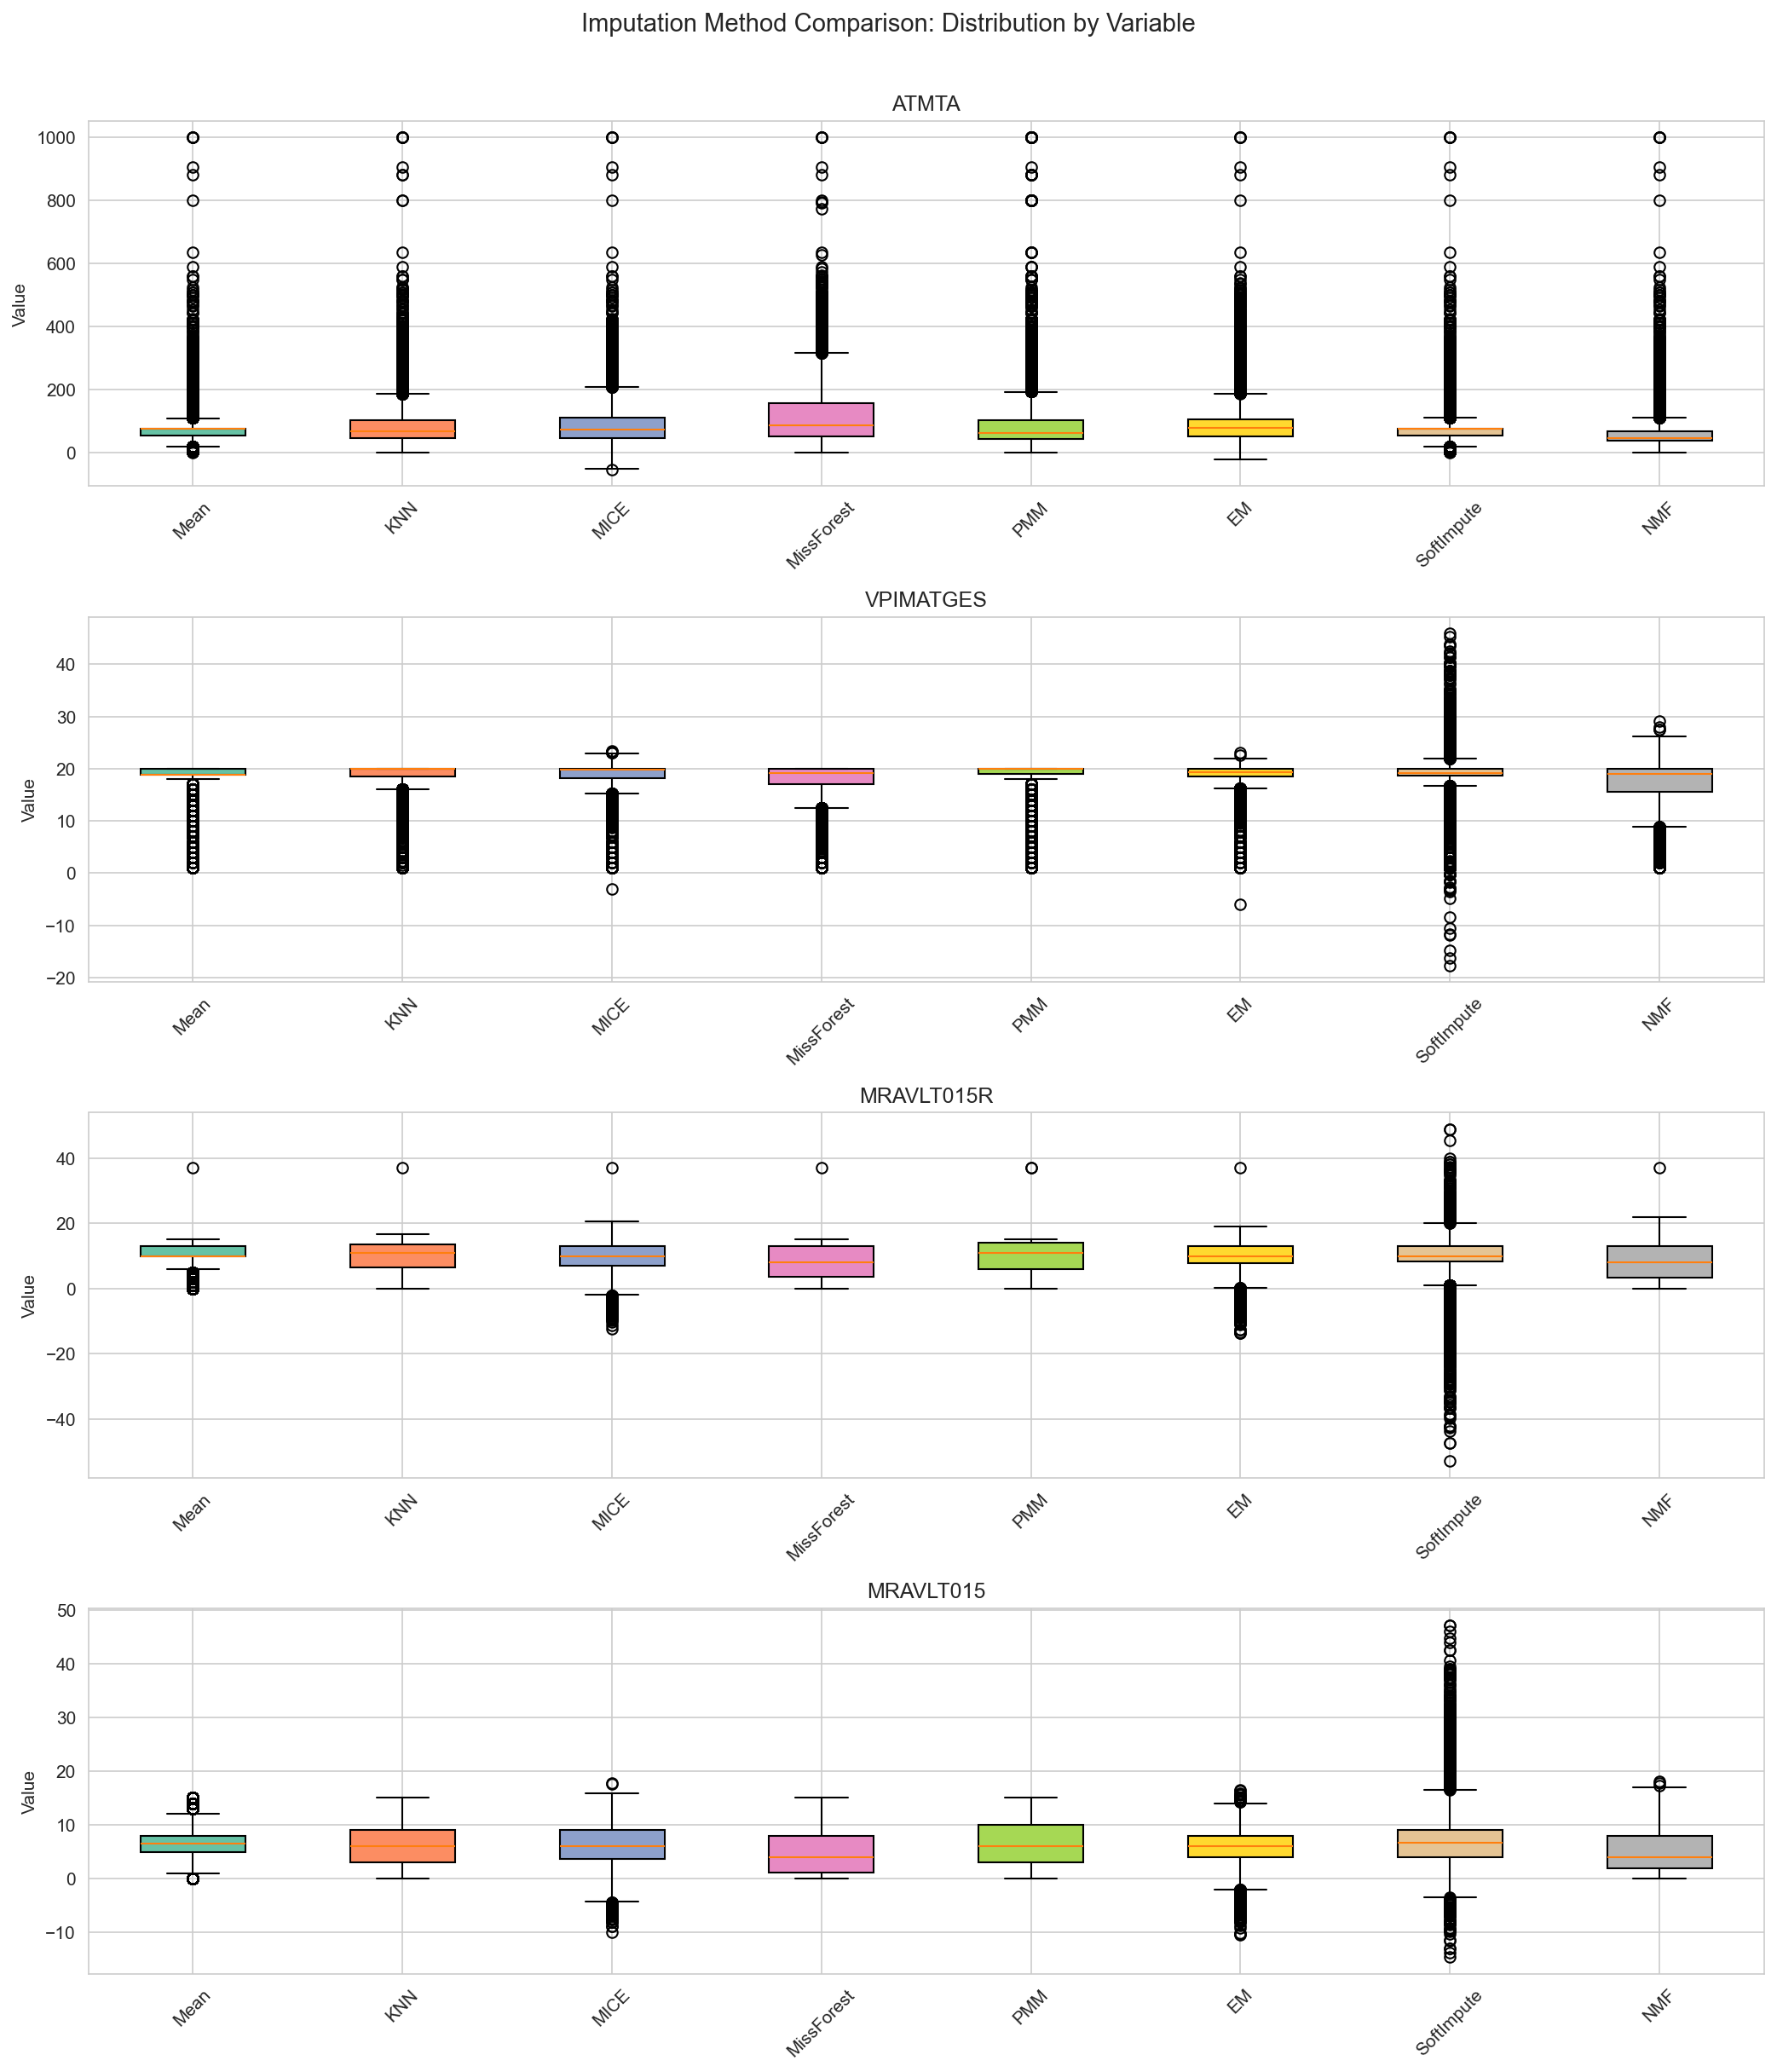

Saved: imputation_comparison_boxplots.png


In [13]:
# Figure: Distribution comparison across methods for selected variables
selected_vars = ELIGIBLE_VARS[:4]  # First 4 variables for visualisation
methods_list = list(imputed_datasets.keys())

fig, axes = plt.subplots(len(selected_vars), 1, figsize=(14, 4 * len(selected_vars)))

for idx, var in enumerate(selected_vars):
    ax = axes[idx]
    box_data = [imputed_datasets[m][var].values for m in methods_list]
    bp = ax.boxplot(box_data, labels=methods_list, patch_artist=True)
    
    colors = sns.color_palette('Set2', len(methods_list))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.set_title(f'{var}', fontsize=12)
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Imputation Method Comparison: Distribution by Variable', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'imputation_comparison_boxplots.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: imputation_comparison_boxplots.png')

In [14]:
# Save summary
summary_df.to_csv(os.path.join(RESULTS_DIR, 'Imputation_Summary.csv'), index=False)

# Save imputed datasets dict for downstream use
with open(os.path.join(RESULTS_DIR, 'imputed_datasets.pkl'), 'wb') as f:
    pickle.dump(imputed_datasets, f, protocol=4)

print('\n=== Notebook 1 Complete ===')
print(f'8 imputed datasets saved to {IMPUTED_DIR}')
print(f'Imputation flags saved to {IMPUTED_DIR}/Imputation_Flags.csv')


=== Notebook 1 Complete ===
8 imputed datasets saved to ../data/imputed_csv
Imputation flags saved to ../data/imputed_csv/Imputation_Flags.csv
